# CMAPSS FD001 Exploratory Data Analysis


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [16]:

df = pd.read_csv('../data/raw/train_FD001.txt', sep=r'\s+', header=None, names=['unit', 'cycle', 'os1', 'os2', 'os3'] + [f's{i}' for i in range(1, 22)])

df1 = pd.read_csv('../data/raw/test_FD001.txt', sep=r'\s+', header=None, names=['unit', 'cycle', 'os1', 'os2', 'os3'] + [f's{i}' for i in range(1, 22)])

print("Training Data Shape:", df.shape)
print("Test Data Shape:", df1.shape)
print("Unique Units in Training Data:", df['unit'].nunique())
print("Unique Units in Test Data:", df1['unit'].nunique())

Training Data Shape: (20631, 26)
Test Data Shape: (13096, 26)
Unique Units in Training Data: 100
Unique Units in Test Data: 100


In [17]:
df['RUL'] = df.groupby('unit')['cycle'].transform('max') - df['cycle']
print("Min RUL:", df['RUL'].min())
print("Max RUL:", df['RUL'].max())
print("Mean RUL:", df['RUL'].mean())
df[['unit', 'cycle', 'RUL']].head()

Min RUL: 0
Max RUL: 361
Mean RUL: 107.80786195530997


,unit,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


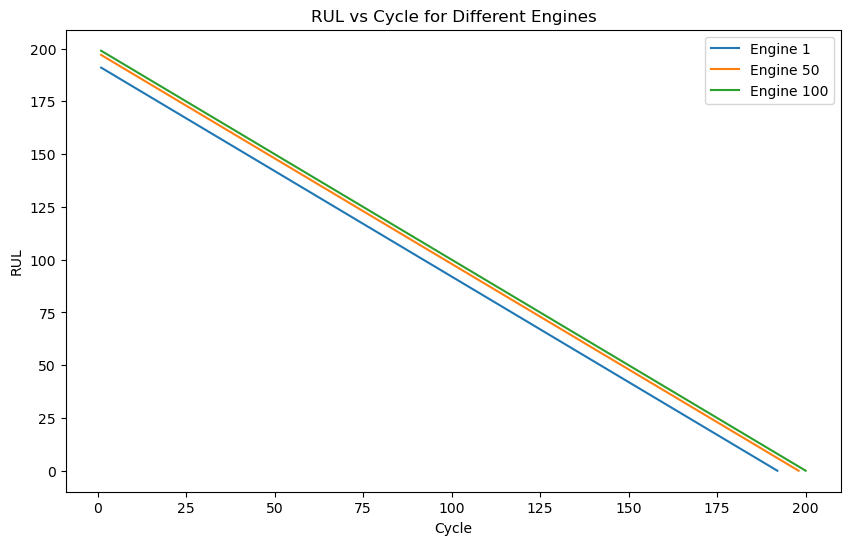

In [20]:
engine_1 = df[df['unit'] == 1]
engine_50 = df[df['unit'] == 50]
engine_100 = df[df['unit'] == 100]

plt.figure(figsize=(10, 6))

plt.plot(engine_1['cycle'],
         engine_1['RUL'],
         label='Engine 1')

plt.plot(engine_50['cycle'],
         engine_50['RUL'],
         label='Engine 50')

plt.plot(engine_100['cycle'],
         engine_100['RUL'],
         label='Engine 100')

plt.xlabel('Cycle')
plt.ylabel('RUL')

plt.title('RUL vs Cycle for Different Engines')
plt.legend()

In [23]:
sensor_cols = [f's{i}' for i in range(1, 22)]

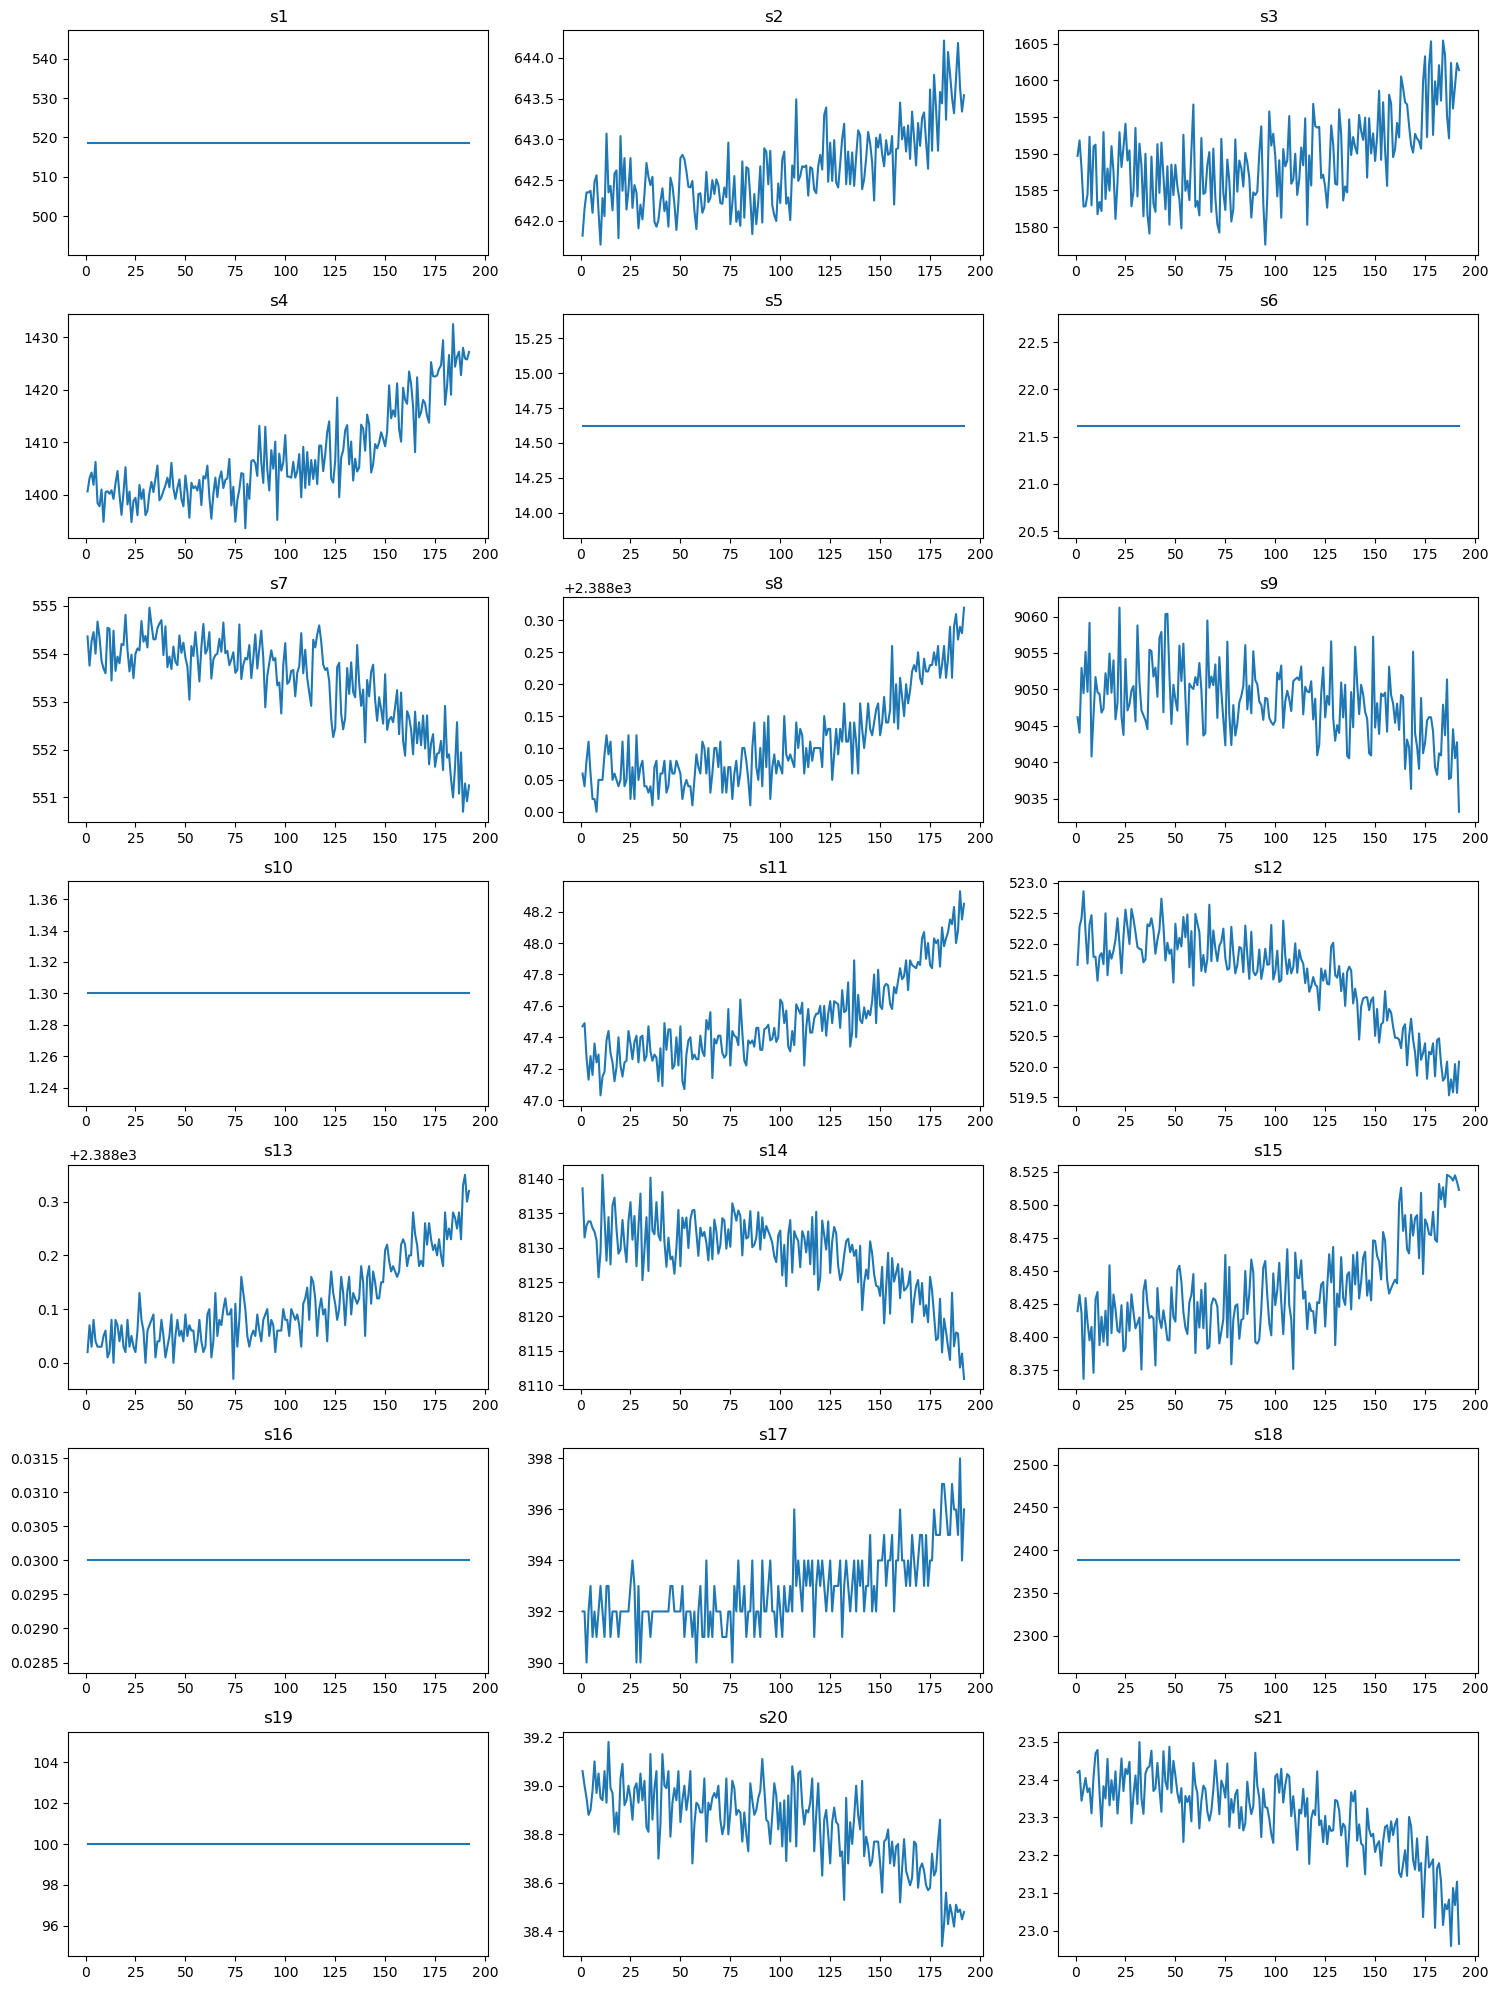

In [24]:
fig, axes = plt.subplots(7, 3, figsize=(15,20))

for ax, sensor in zip(axes.flatten(), sensor_cols):
    ax.plot(engine_1['cycle'], engine_1[sensor])
    ax.set_title(sensor)

plt.tight_layout()
plt.show()


In [25]:
sensor_variance = df[sensor_cols].var()

sensor_variance = sensor_variance.sort_values()

print(sensor_variance)

s19    0.000000e+00
s18    0.000000e+00
s16    2.422479e-28
s10    2.172333e-25
s5     1.152399e-23
s1     4.273435e-21
s6     1.929279e-06
s15    1.406628e-03
s8     5.038938e-03
s13    5.172330e-03
s21    1.171825e-02
s20    3.266927e-02
s11    7.133568e-02
s2     2.500533e-01
s12    5.439850e-01
s7     7.833883e-01
s17    2.398667e+00
s3     3.759099e+01
s4     8.101089e+01
s14    3.639005e+02
s9     4.876536e+02
dtype: float64


Sensors dropped from model input:
- s1: zero variance across all engines, confirmed by PSI 0.0
- s5: zero variance, flat line in time series plot
- s6: near-zero variance (1.9e-6), no degradation signal
- s10: zero variance, confirmed by PSI 0.0
- s16: zero variance, confirmed by PSI 0.0
- s18: zero variance, confirmed by PSI 0.0
- s19: zero variance, confirmed by PSI 0.0

Remaining signal sensors: 14 features for LSTM input.
os1, os2, os3 retained as operational context features.

In [33]:
import sys
sys.path.append('..')
import importlib
import pipeline.preprocess
importlib.reload(pipeline.preprocess)
from pipeline.preprocess import create_windowed_features

In [34]:
signal_cols = [c for c in df.columns if c.startswith('s')]
x, y = create_windowed_features(df, signal_cols)


In [37]:
df = df.drop(columns=['s1', 's5', 's6', 's10', 's16', 's18', 's19'], errors='ignore')

In [38]:
import importlib
import pipeline.preprocess
importlib.reload(pipeline.preprocess)
from pipeline.preprocess import fit_scaler, apply_scaler, create_windowed_features




In [41]:
signal_cols = [c for c in df.columns if c.startswith('s')]
x, y = create_windowed_features(df, signal_cols)
print("Windowed Features Shape:", x.shape)
print("Windowed Labels Shape:", y.shape)

Windowed Features Shape: (17731, 30, 14)
Windowed Labels Shape: (17731,)


In [42]:
scaler = fit_scaler(df, signal_cols)
df_scaled = apply_scaler(df, scaler, signal_cols)
df1_scaled = apply_scaler(df1, scaler, signal_cols)
print(df_scaled[signal_cols].min())
print(df_scaled[signal_cols].max())

s2     0.0
s3     0.0
s4     0.0
s7     0.0
s8     0.0
s9     0.0
s11    0.0
s12    0.0
s13    0.0
s14    0.0
s15    0.0
s17    0.0
s20    0.0
s21    0.0
dtype: float64
s2     1.0
s3     1.0
s4     1.0
s7     1.0
s8     1.0
s9     1.0
s11    1.0
s12    1.0
s13    1.0
s14    1.0
s15    1.0
s17    1.0
s20    1.0
s21    1.0
dtype: float64


In [43]:
import pickle
import os
os.makedirs('../data/processed', exist_ok=True)
with open('../data/processed/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler saved.")

Scaler saved.


In [ ]:
df_scaled['RUL'] = df['RUL']

In [46]:
x_train, y_train = create_windowed_features(df_scaled, signal_cols)

In [47]:
print("Windowed Features Shape:", x_train.shape)
print("Windowed Labels Shape:", y_train.shape)

Windowed Features Shape: (17731, 30, 14)
Windowed Labels Shape: (17731,)


In [48]:
np.save('../data/processed/x_train.npy', x_train)
np.save('../data/processed/y_train.npy', y_train)

In [51]:
print("Windowed Features Shape:", x_train.shape)

print("Windowed Labels Mean:", y_train.mean())
print("Windowed Labels max:", y_train.max())
print("X_train contains NaN:", np.isnan(x_train).any())
print("y_train contains NaN:", np.isnan(y_train).any())

Windowed Features Shape: (17731, 30, 14)
Windowed Labels Mean: 94.15064012182054
Windowed Labels max: 332
X_train contains NaN: False
y_train contains NaN: False


FD001 contains 100 training engines and 100 test engines operating under a single condition with a single fault mode. Each engine has 21 sensor readings and 3 operational settings per cycle. Source: Saxena and Goebel 2008.

RUL labels are computed using the linear degradation assumption: for each engine, RUL at cycle t equals the maximum cycle for that engine minus t. This assumes the engine degrades linearly from start to failure.


Seven sensors dropped due to near-zero variance and PSI of 0.0: s1, s5, s6, s10, s16, s18, s19. These sensors show no variation across the full dataset and carry no degradation signal. Remaining signal sensors: 14 features.

Sliding window size of 30 cycles used, following the standard for CMAPSS established by Heimes 2008 and Wu et al. 2019. Each window produces one training sample.

MinMaxScaler fitted on training set only and applied to both training and test sets. Fitting on training data only prevents data leakage from the test set into the scaler parameters.

X_train shape: (17731, 30, 14). y_train shape: (17731,). Data saved to data/processed/ as numpy arrays ready for LSTM training in Phase 4.